# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [27]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for name, model in base_models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_macro'
    )

    baseline_results[name] = (scores.mean(), scores.std())


# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [29]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    # YOUR CODE HERE
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear'],

}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

svm_grid_search.fit(X_train, y_train)


print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [30]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

svm_results = pd.DataFrame(svm_grid_search.cv_results_)

svm_results = svm_results[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')

svm_results.head(10)


,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
    'n_estimators': randint(50, 500),
    'max_depth': [None] + list(range(2, 20)),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5],

}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 19, 'max_features': 0.5, 'min_samples_split': 4, 'n_estimators': 356}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [32]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

test_results = []

models_to_evaluate = {
    'SVM baseline': base_models['SVM'],
    'SVM Grid Search': svm_grid_search.best_estimator_,
    'RF baseline': base_models['RandomForest'],
    'RF Random Search': rf_random_search.best_estimator_,
}

for name, model in models_to_evaluate.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

    test_f1 = f1_score(y_test, y_pred, average='macro')

    if name == 'SVM baseline':
        cv_mean, cv_std = baseline_results['SVM']
    elif name == 'RF baseline':
        cv_mean, cv_std = baseline_results['RandomForest']
    elif name == 'SVM Grid Search':
        cv_mean, cv_std = svm_grid_search.best_score_, 0
    else:
        cv_mean, cv_std = rf_random_search.best_score_, 0

    test_results.append({
        'Модель': name,
        'CV F1 (mean±std)': f'{cv_mean:.4f} ± {cv_std:.4f}',
        'Test F1': round(test_f1, 4)
    })

results_table = pd.DataFrame(test_results)
results_table


# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |


SVM baseline
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


SVM Grid Search
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


RF baseline
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0

,Модель,CV F1 (mean±std),Test F1
0,SVM baseline,0.9694 ± 0.0193,0.9812
1,SVM Grid Search,0.9786 ± 0.0000,0.9812
2,RF baseline,0.9504 ± 0.0255,0.9526
3,RF Random Search,0.9554 ± 0.0000,0.9526


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

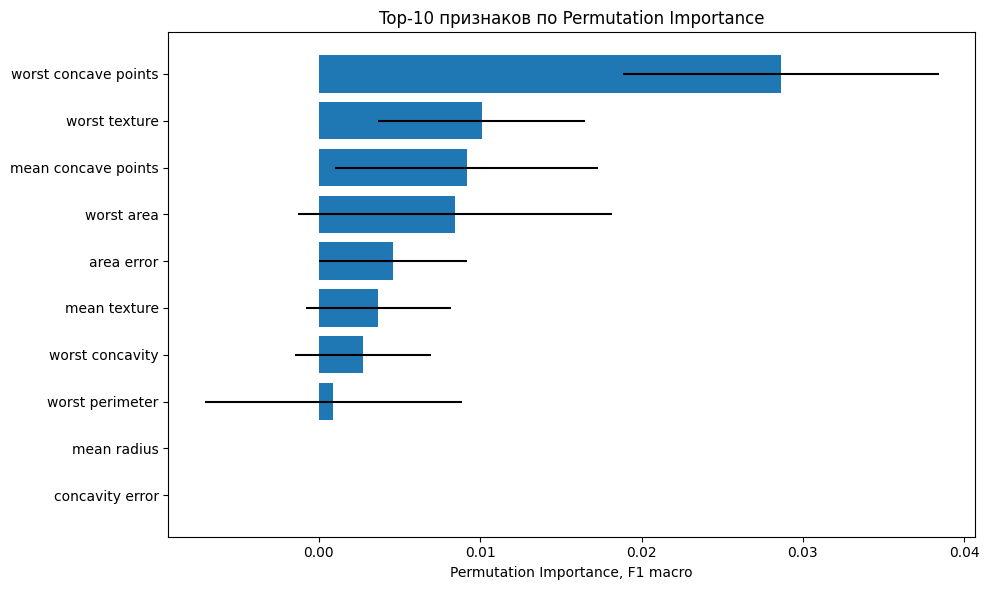

,feature,importance_mean,importance_std
27,worst concave points,0.028624,0.009783
21,worst texture,0.010080,0.006399
7,mean concave points,0.009154,0.008154
23,worst area,0.008427,0.009737
13,area error,0.004593,0.004593
1,mean texture,0.003674,0.004500
26,worst concavity,0.002756,0.004209
22,worst perimeter,0.000892,0.007949
0,mean radius,0.000000,0.000000
16,concavity error,0.000000,0.000000


In [33]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

pi_importances = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': pi_result.importances_mean,
    'importance_std': pi_result.importances_std,
}).sort_values('importance_mean', ascending=False)

top10_pi = pi_importances.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top10_pi['feature'][::-1],
    top10_pi['importance_mean'][::-1],
    xerr=top10_pi['importance_std'][::-1]
)
plt.xlabel('Permutation Importance, F1 macro')
plt.title('Top-10 признаков по Permutation Importance')
plt.tight_layout()
plt.show()

top10_pi

In [34]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

rf_importances = pd.DataFrame({
    'feature': feature_names,
    'rf_importance': best_rf.feature_importances_,
}).sort_values('rf_importance', ascending=False)

comparison_importances = pi_importances.merge(
    rf_importances,
    on='feature'
)

comparison_importances['pi_rank'] = comparison_importances['importance_mean'].rank(
    ascending=False,
    method='min'
)

comparison_importances['rf_rank'] = comparison_importances['rf_importance'].rank(
    ascending=False,
    method='min'
)

comparison_importances = comparison_importances.sort_values('pi_rank')

display(comparison_importances.head(10))

top5_pi = comparison_importances.sort_values('pi_rank')['feature'].head(5).tolist()
top5_rf = comparison_importances.sort_values('rf_rank')['feature'].head(5).tolist()

print('Top-5 по Permutation Importance:')
print(top5_pi)

print('\nTop-5 по встроенной важности RF:')
print(top5_rf)

print('\nСовпадают ли множества top-5:', set(top5_pi) == set(top5_rf))

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?



,feature,importance_mean,importance_std,rf_importance,pi_rank,rf_rank
0,worst concave points,0.028624,0.009783,0.186988,1.0,2.0
1,worst texture,0.010080,0.006399,0.021982,2.0,6.0
2,mean concave points,0.009154,0.008154,0.115230,3.0,5.0
3,worst area,0.008427,0.009737,0.141626,4.0,3.0
4,area error,0.004593,0.004593,0.013809,5.0,10.0
5,mean texture,0.003674,0.004500,0.018300,6.0,8.0
6,worst concavity,0.002756,0.004209,0.011015,7.0,12.0
7,worst perimeter,0.000892,0.007949,0.226221,8.0,1.0
20,radius error,0.000000,0.000000,0.003920,9.0,22.0
21,mean fractal dimension,0.000000,0.000000,0.001400,9.0,30.0


Top-5 по Permutation Importance:
['worst concave points', 'worst texture', 'mean concave points', 'worst area', 'area error']

Top-5 по встроенной важности RF:
['worst perimeter', 'worst concave points', 'worst area', 'worst radius', 'mean concave points']

Совпадают ли множества top-5: False


Порядок признаков может не совпадать.

Permutation Importance показывает, насколько падает качество модели,
если перемешать конкретный признак на тестовой выборке. Это ближе к влиянию
признака на итоговую метрику.

feature_importances_ у RandomForest считается по уменьшению impurity внутри
деревьев. Этот метод может завышать важность признаков, которые чаще выбирались
для разбиений, и чувствителен к коррелированным признакам.

Если признак имеет высокий PI, но низкую встроенную важность, значит модель
реально зависит от него для качества, но в деревьях его вклад мог быть
распределен между коррелированными признаками.

Если встроенная важность высокая, а PI низкий, признак часто использовался
в разбиениях, но его перемешивание почти не ухудшает итоговое качество.

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

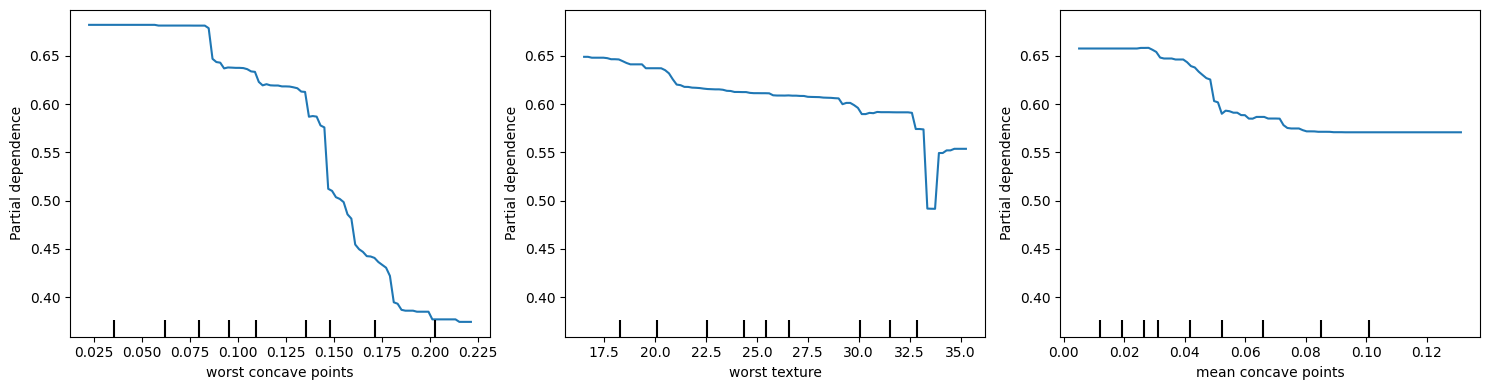

In [35]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_features = pi_importances.head(3)['feature'].tolist()
top3_idx = [list(feature_names).index(feature) for feature in top3_features]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=top3_idx,
    feature_names=feature_names,
    kind='average',
    ax=ax
)

plt.tight_layout()
plt.show()

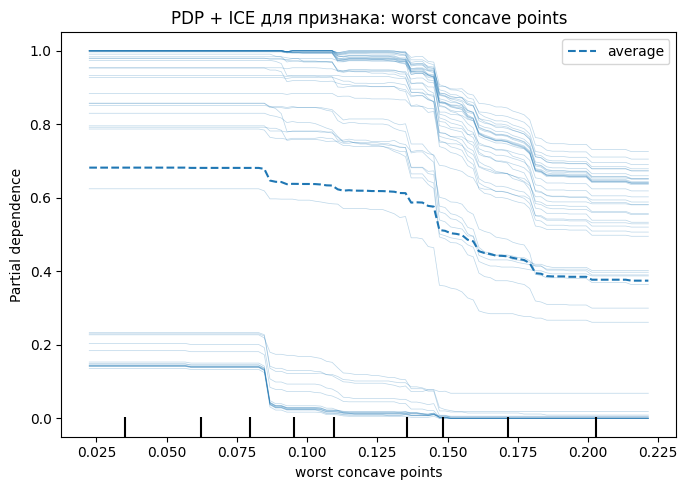

In [36]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

ttop_feature = pi_importances.iloc[0]['feature']
top_feature_idx = list(feature_names).index(top_feature)

fig, ax = plt.subplots(figsize=(7, 5))

PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=[top_feature_idx],
    feature_names=feature_names,
    kind='both',
    subsample=50,
    random_state=42,
    ax=ax
)

plt.title(f'PDP + ICE для признака: {top_feature}')
plt.tight_layout()
plt.show()

# ICE-кривые показывают, одинаково ли признак влияет на разные объекты.
# Если линии идут примерно параллельно и в одном направлении, эффект однородный.
# Если линии сильно расходятся или имеют разную форму, значит влияние признака
# зависит от конкретного объекта и взаимодействий с другими признаками.


## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [37]:
# Установка SHAP (если не установлен)
!pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    print('shap_values для каждого класса:')
    for class_idx, values in enumerate(shap_values):
        print(f'Класс {class_idx}: {values.shape}')
else:
    print('shap_values shape:', shap_values.shape)



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
shap_values shape: (114, 30, 2)


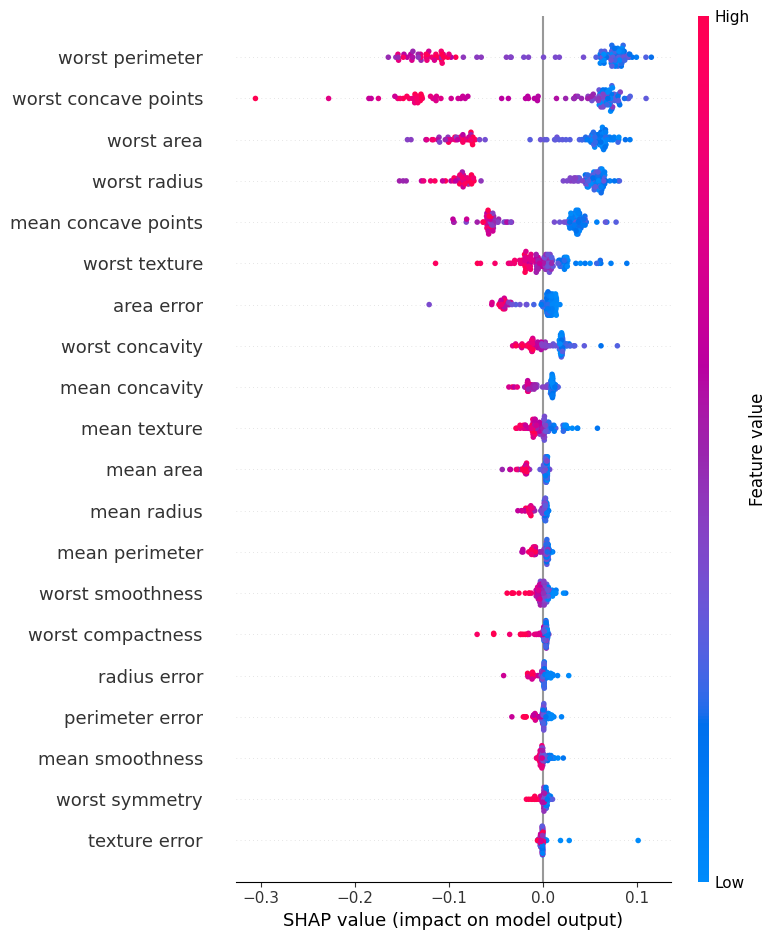

,feature,shap_importance
22,worst perimeter,0.089872
27,worst concave points,0.084154
23,worst area,0.067528
20,worst radius,0.067161
7,mean concave points,0.045661
21,worst texture,0.019292
13,area error,0.018486
26,worst concavity,0.016251
6,mean concavity,0.011538
1,mean texture,0.010440


Top-5 по SHAP:
['worst perimeter', 'worst concave points', 'worst area', 'worst radius', 'mean concave points']

Top-5 по PI:
['worst concave points', 'worst texture', 'mean concave points', 'worst area', 'area error']

Совпадают ли множества top-5: False


In [38]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

if isinstance(shap_values, list):
    shap_values_class_1 = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_class_1 = shap_values[:, :, 1]
else:
    shap_values_class_1 = shap_values

shap.summary_plot(shap_values_class_1, X_test)

shap_importances = pd.DataFrame({
    'feature': feature_names,
    'shap_importance': np.abs(shap_values_class_1).mean(axis=0),
}).sort_values('shap_importance', ascending=False)

display(shap_importances.head(10))

top5_shap = shap_importances['feature'].head(5).tolist()
top5_pi = pi_importances['feature'].head(5).tolist()

print('Top-5 по SHAP:')
print(top5_shap)

print('\nTop-5 по PI:')
print(top5_pi)

print('\nСовпадают ли множества top-5:', set(top5_shap) == set(top5_pi))

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


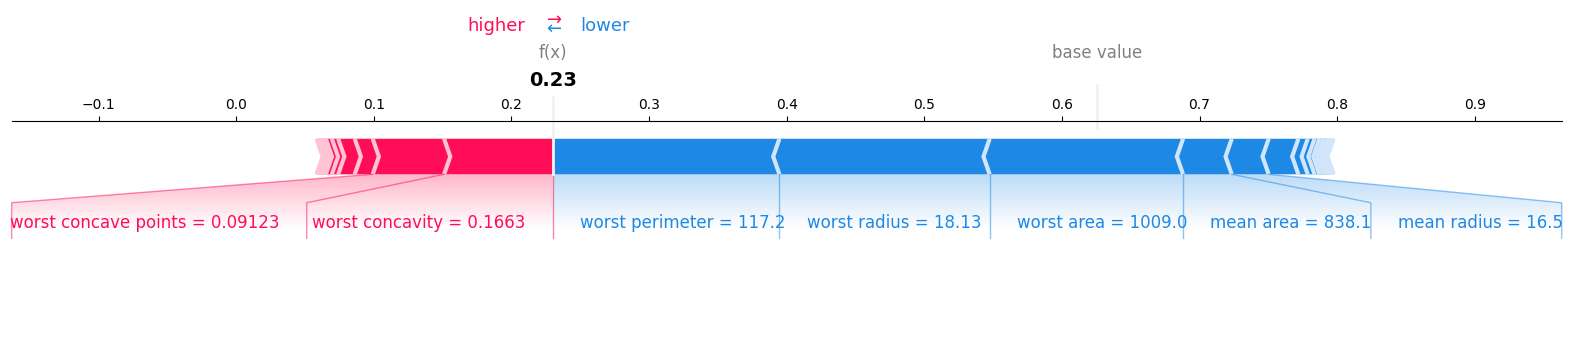

,feature,shap_value,abs_shap_value,feature_value
22,worst perimeter,-0.164665,0.164665,117.20000
20,worst radius,-0.152780,0.152780,18.13000
23,worst area,-0.140515,0.140515,1009.00000
26,worst concavity,0.078988,0.078988,0.16630
27,worst concave points,0.051866,0.051866,0.09123
3,mean area,-0.035389,0.035389,838.10000
0,mean radius,-0.026838,0.026838,16.50000
2,mean perimeter,-0.021552,0.021552,106.60000
6,mean concavity,0.013071,0.013071,0.05862
7,mean concave points,0.012010,0.012010,0.04835


In [39]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
error_idx = errors[0]

if isinstance(shap_values, list):
    shap_values_class_1 = shap_values[1]
    expected_value = explainer.expected_value[1]
elif len(shap_values.shape) == 3:
    shap_values_class_1 = shap_values[:, :, 1]
    expected_value = explainer.expected_value[1]
else:
    shap_values_class_1 = shap_values
    expected_value = explainer.expected_value

shap.initjs()

shap.force_plot(
    expected_value,
    shap_values_class_1[error_idx],
    X_test.iloc[error_idx],
    matplotlib=True
)

error_contrib = pd.DataFrame({
    'feature': feature_names,
    'shap_value': shap_values_class_1[error_idx],
    'abs_shap_value': np.abs(shap_values_class_1[error_idx]),
    'feature_value': X_test.iloc[error_idx].values,
}).sort_values('abs_shap_value', ascending=False)

display(error_contrib.head(10))

# Главные признаки, которые повлияли на ошибку, это признаки с самым большим abs_shap_value.
# Положительные SHAP-значения тянут предсказание к классу 1, отрицательные — к классу 0.


## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [40]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())



Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

Test F1 с дополнительными признаками: 1.0000


,feature,importance_mean,importance_std
30,leaky_feature,0.503274,0.067463
0,mean radius,0.000000,0.000000
1,mean texture,0.000000,0.000000
29,worst fractal dimension,0.000000,0.000000
28,worst symmetry,0.000000,0.000000
27,worst concave points,0.000000,0.000000
26,worst concavity,0.000000,0.000000
25,worst compactness,0.000000,0.000000
24,worst smoothness,0.000000,0.000000
23,worst area,0.000000,0.000000


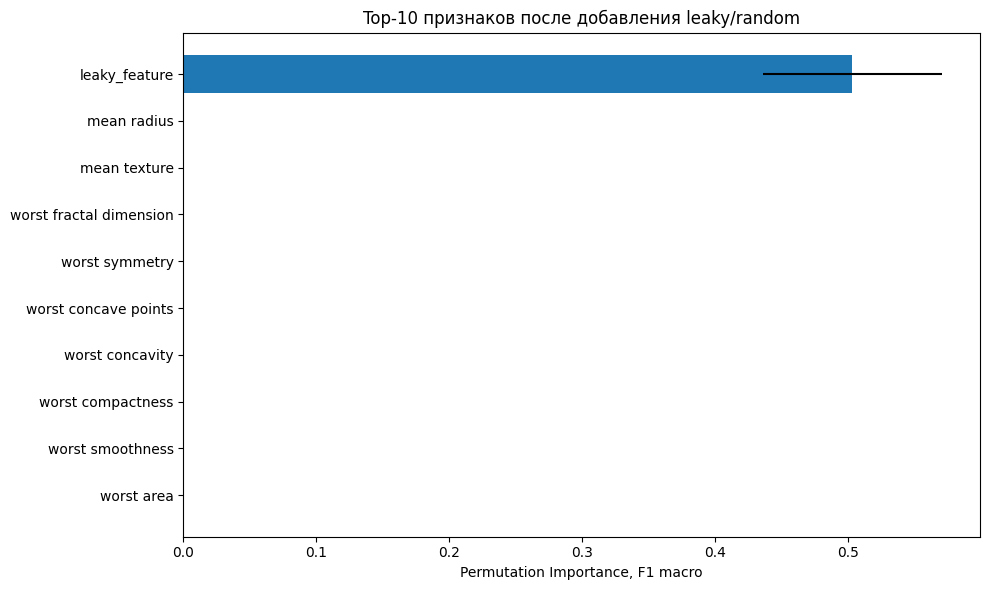

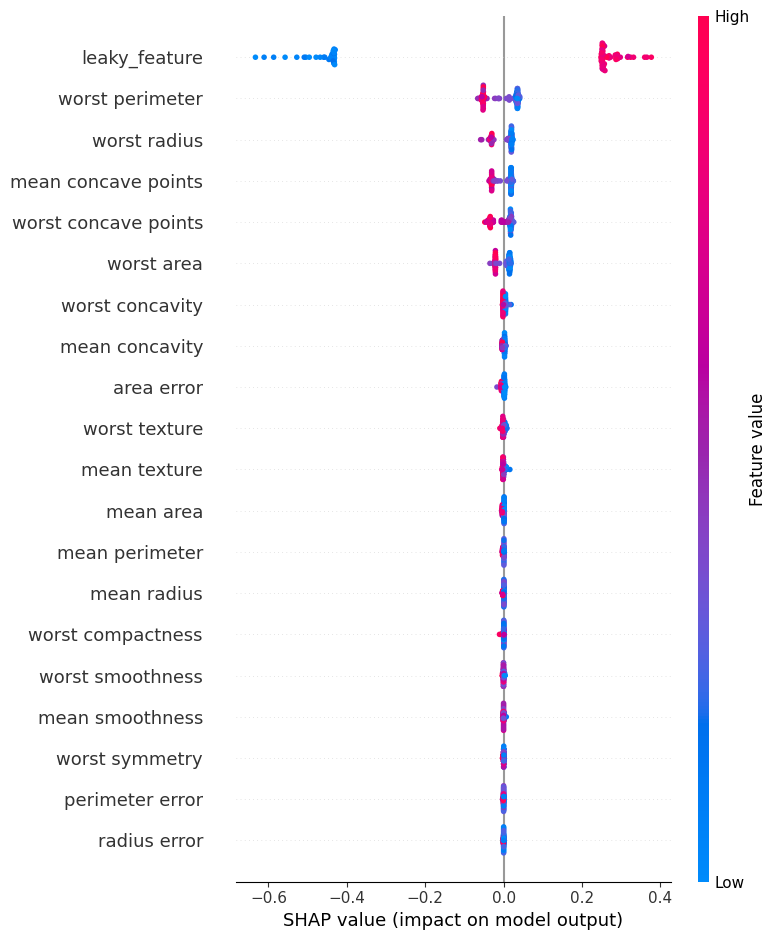

,feature,shap_importance
30,leaky_feature,0.337861
22,worst perimeter,0.039217
20,worst radius,0.023499
7,mean concave points,0.023105
27,worst concave points,0.021669
23,worst area,0.016654
26,worst concavity,0.003026
6,mean concavity,0.002914
13,area error,0.002864
21,worst texture,0.002208


In [41]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

rf_ext = RandomForestClassifier(
    **rf_random_search.best_params_,
    random_state=42,
    n_jobs=-1
)

rf_ext.fit(X_train_ext, y_train)

y_pred_ext = rf_ext.predict(X_test_ext)
test_f1_ext = f1_score(y_test, y_pred_ext, average='macro')

print(f'Test F1 с дополнительными признаками: {test_f1_ext:.4f}')

pi_ext_result = permutation_importance(
    rf_ext,
    X_test_ext,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

pi_ext_importances = pd.DataFrame({
    'feature': X_train_ext.columns,
    'importance_mean': pi_ext_result.importances_mean,
    'importance_std': pi_ext_result.importances_std,
}).sort_values('importance_mean', ascending=False)

display(pi_ext_importances.head(10))


plt.figure(figsize=(10, 6))

top10_pi_ext = pi_ext_importances.head(10)

plt.barh(
    top10_pi_ext['feature'][::-1],
    top10_pi_ext['importance_mean'][::-1],
    xerr=top10_pi_ext['importance_std'][::-1]
)

plt.xlabel('Permutation Importance, F1 macro')
plt.title('Top-10 признаков после добавления leaky/random')
plt.tight_layout()
plt.show()

explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)

if isinstance(shap_values_ext, list):
    shap_values_ext_class_1 = shap_values_ext[1]
elif len(shap_values_ext.shape) == 3:
    shap_values_ext_class_1 = shap_values_ext[:, :, 1]
else:
    shap_values_ext_class_1 = shap_values_ext

shap.summary_plot(shap_values_ext_class_1, X_test_ext)

shap_ext_importances = pd.DataFrame({
    'feature': X_train_ext.columns,
    'shap_importance': np.abs(shap_values_ext_class_1).mean(axis=0),
}).sort_values('shap_importance', ascending=False)

display(shap_ext_importances.head(10))

# a) leaky_feature должен оказаться среди самых важных по PI, потому что он почти напрямую содержит target.
#    Метрика на тесте выросла из-за утечки данных: модель получила признак, который не должен быть доступен в реальной задаче.

# б) В SHAP leaky_feature должен получить большой средний |SHAP| и попасть в верхние строки summary plot.

# в) random_feature можно считать шумовым, если его PI и средний |SHAP| близки к нулю и он не попадает в топ важных признаков.


## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [42]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
summary_table = results_table.copy()

summary_table['Выводы'] = [
    'Базовая SVM с масштабированием признаков',
    'Grid Search подбирает C, gamma и kernel',
    'Базовый случайный лес без подбора параметров',
    'Random Search подбирает параметры леса',
]

display(summary_table)
best_baseline_f1 = summary_table.loc[
    summary_table['Модель'].isin(['SVM baseline', 'RF baseline']),
    'Test F1'
].max()

best_tuned_f1 = summary_table.loc[
    summary_table['Модель'].isin(['SVM Grid Search', 'RF Random Search']),
    'Test F1'
].max()

print(f'Лучший baseline Test F1: {best_baseline_f1:.4f}')
print(f'Лучший tuned Test F1: {best_tuned_f1:.4f}')
print(f'Изменение качества: {best_tuned_f1 - best_baseline_f1:.4f}')

print('Top-5 PI:', top5_pi)
print('Top-5 SHAP:', top5_shap)
print('Совпадают ли top-5:', set(top5_pi) == set(top5_shap))


# 1. Тюнинг улучшил модели настолько, насколько вырос Test F1 по сравнению с baseline.
#    Если прирост маленький, значит базовые параметры уже были достаточно хорошими.

# 2. Топ-признаки по PI и SHAP могут не совпадать.
#    PI показывает, насколько падает качество модели при перемешивании признака.
#    SHAP показывает вклад признаков в конкретные предсказания.

# 3. Без Pipeline масштабирование могло бы быть сделано до cross-validation,
#    что привело бы к утечке информации из validation-fold в train-fold.
#    Pipeline применяет StandardScaler отдельно внутри каждого fold.

# 4. В реальном проекте PI удобно использовать для быстрой проверки важности признаков,
#    а SHAP — для детального объяснения глобального поведения модели и отдельных предсказаний.


,Модель,CV F1 (mean±std),Test F1,Выводы
0,SVM baseline,0.9694 ± 0.0193,0.9812,Базовая SVM с масштабированием признаков
1,SVM Grid Search,0.9786 ± 0.0000,0.9812,"Grid Search подбирает C, gamma и kernel"
2,RF baseline,0.9504 ± 0.0255,0.9526,Базовый случайный лес без подбора параметров
3,RF Random Search,0.9554 ± 0.0000,0.9526,Random Search подбирает параметры леса


Лучший baseline Test F1: 0.9812
Лучший tuned Test F1: 0.9812
Изменение качества: 0.0000
Top-5 PI: ['worst concave points', 'worst texture', 'mean concave points', 'worst area', 'area error']
Top-5 SHAP: ['worst perimeter', 'worst concave points', 'worst area', 'worst radius', 'mean concave points']
Совпадают ли top-5: False


## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


/Users/alex/Documents/ml-course-homeworks-2026/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/alex/Documents/ml-course-homeworks-2026/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/alex/Documents/ml-course-homeworks-2026/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


Лучший результат Optuna: 0.9576
Лучшие параметры: {'n_estimators': 470, 'max_depth': 9, 'min_samples_split': 3, 'max_features': 0.5}
Лучший результат Random Search: 0.9554


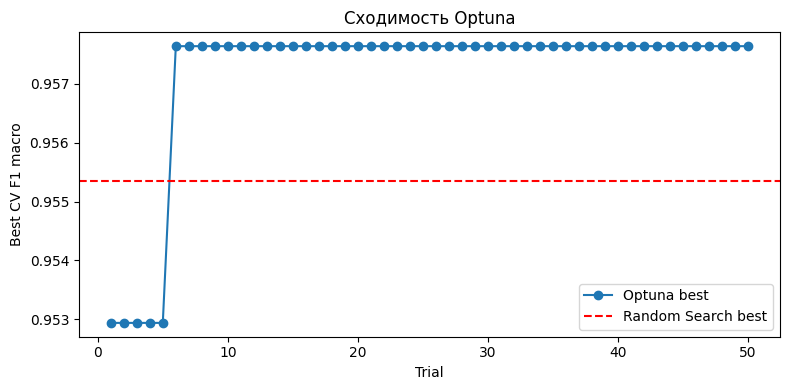

In [43]:
!pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_categorical(
            'max_depth',
            [None] + list(range(2, 20))
        ),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical(
            'max_features',
            ['sqrt', 'log2', 0.5]
        ),
    }

    model = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1
    )

    return scores.mean()
n_trials = 50

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=n_trials)

print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")
print(f"Лучший результат Random Search: {rf_random_search.best_score_:.4f}")

best_values_over_time = []
current_best = -np.inf

for trial in study.trials:
    if trial.value is not None:
        current_best = max(current_best, trial.value)
    best_values_over_time.append(current_best)

plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(best_values_over_time) + 1),
    best_values_over_time,
    marker='o',
    label='Optuna best'
)

plt.axhline(
    rf_random_search.best_score_,
    color='red',
    linestyle='--',
    label='Random Search best'
)

plt.xlabel('Trial')
plt.ylabel('Best CV F1 macro')
plt.title('Сходимость Optuna')
plt.legend()
plt.tight_layout()
plt.show()
